# Filter Benchmark + EfficientNetV2-L (Folder-Based)

This notebook trains EfficientNetV2-L using pre-split `train/`, `val/`, and `test/` folders produced by the patient-level splitter.
It keeps the training notebook focused on the model recipe and removes split logic from the critical path.

In [1]:
import os
import json
import copy
import random
import warnings
from pathlib import Path
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import efficientnet_v2_l

from monai.losses import FocalLoss
from monai.utils import set_determinism

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'filter_benchmark_efficientnet_v2l_folder_based'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
NUM_EPOCHS = 40
PATIENCE = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
USE_CLAHE = True
GEOMETRY_MODE = 'direct_resize'

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
print('DATA_ROOT:', DATA_ROOT)
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM (GB): 50.86216192
DATA_ROOT: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits
RESULTS_DIR: /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2l_folder_based
MODELS_DIR: /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2l_folder_based


In [2]:
train_dir = Path(DATA_ROOT) / 'train'
val_dir = Path(DATA_ROOT) / 'val'
test_dir = Path(DATA_ROOT) / 'test'

assert train_dir.exists(), f'Missing train folder: {train_dir}'
assert val_dir.exists(), f'Missing val folder: {val_dir}'
assert test_dir.exists(), f'Missing test folder: {test_dir}'

class_names = sorted([path.name for path in train_dir.iterdir() if path.is_dir()])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
FINAL_CLASSES = class_names
print('Classes:', class_names)

def list_split_frames(split_dir: Path) -> pd.DataFrame:
    rows = []
    for class_name in class_names:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
                rows.append({'image_path': str(image_path), 'target': class_to_idx[class_name], 'final_label': class_name})
    return pd.DataFrame(rows)

train_df = list_split_frames(train_dir)
val_df = list_split_frames(val_dir)
test_df = list_split_frames(test_dir)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))
print('Train label distribution:')
print(train_df['final_label'].value_counts())

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Split sizes:
train: 1067 val: 234 test: 267
Train label distribution:
final_label
Lithiasis        505
Stricture        255
Normal           197
Biliary_Leaks    110
Name: count, dtype: int64


In [3]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas

def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def preprocess_image(image: Image.Image, geometry_mode='direct_resize', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image

class FolderDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable, use_clahe=False, geometry_mode='direct_resize'):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_clahe = use_clahe
        self.geometry_mode = geometry_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        image = self.transform(image)
        return image, int(row['target'])

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
])

eval_transform = T.Compose([
    T.ToTensor(),
])

In [4]:
# Compute dataset-specific normalization from the training folder after preprocessing
pixel_sum = np.zeros(3, dtype=np.float64)
pixel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count = 0
for path in train_df['image_path']:
    image = Image.open(path).convert('RGB')
    image = preprocess_image(image, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
    array = np.asarray(image, dtype=np.float64) / 255.0
    pixel_sum += array.sum(axis=(0, 1))
    pixel_sq_sum += (array ** 2).sum(axis=(0, 1))
    pixel_count += array.shape[0] * array.shape[1]

dataset_mean = (pixel_sum / pixel_count).tolist()
dataset_std = np.clip(np.sqrt(pixel_sq_sum / pixel_count - np.square(dataset_mean)), 1e-7, None).tolist()
print('Dataset mean:', [f'{v:.4f}' for v in dataset_mean])
print('Dataset std:', [f'{v:.4f}' for v in dataset_std])

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=dataset_mean, std=dataset_std),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=dataset_mean, std=dataset_std),
])

Dataset mean: ['0.3574', '0.3575', '0.3574']
Dataset std: ['0.2560', '0.2560', '0.2560']


In [5]:
train_ds = FolderDataset(train_df, train_transform, use_clahe=USE_CLAHE, geometry_mode=GEOMETRY_MODE)
val_ds = FolderDataset(val_df, eval_transform, use_clahe=USE_CLAHE, geometry_mode=GEOMETRY_MODE)
test_ds = FolderDataset(test_df, eval_transform, use_clahe=USE_CLAHE, geometry_mode=GEOMETRY_MODE)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
print('Class weights:', class_weights)

Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461], device='cuda:0')


In [6]:
import math

def build_efficientnet_v2_l(num_classes, pretrained=True):
    try:
        from torchvision.models import EfficientNet_V2_L_Weights
        weights = EfficientNet_V2_L_Weights.DEFAULT if pretrained else None
        model = efficientnet_v2_l(weights=weights)
    except Exception:
        model = efficientnet_v2_l(pretrained=pretrained)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics

def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs

def train_model():
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = FocalLoss(to_onehot_y=True)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics['roc_auc_ovo_macro'],
        })
        scheduler.step()
        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_folder_based.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_folder_based.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1

In [7]:
model, history_df, best_epoch, best_val_f1 = train_model()
print(f'Training complete. Best epoch: {best_epoch}, best val macro F1: {best_val_f1:.4f}')

Epoch 01 | train_loss 0.1206 | train_f1 0.5340 | val_f1 0.4290
Epoch 02 | train_loss 0.0753 | train_f1 0.7596 | val_f1 0.4441
Epoch 03 | train_loss 0.0631 | train_f1 0.8154 | val_f1 0.4502
Epoch 04 | train_loss 0.0447 | train_f1 0.8748 | val_f1 0.3955
Epoch 05 | train_loss 0.0380 | train_f1 0.9053 | val_f1 0.4306
Epoch 06 | train_loss 0.0329 | train_f1 0.9163 | val_f1 0.4545
Epoch 07 | train_loss 0.0203 | train_f1 0.9555 | val_f1 0.4738
Epoch 08 | train_loss 0.0211 | train_f1 0.9418 | val_f1 0.4295
Epoch 09 | train_loss 0.0199 | train_f1 0.9597 | val_f1 0.4421
Epoch 10 | train_loss 0.0227 | train_f1 0.9534 | val_f1 0.3551
Epoch 11 | train_loss 0.0172 | train_f1 0.9673 | val_f1 0.4654
Epoch 12 | train_loss 0.0140 | train_f1 0.9677 | val_f1 0.5221
Epoch 13 | train_loss 0.0146 | train_f1 0.9719 | val_f1 0.5237
Epoch 14 | train_loss 0.0121 | train_f1 0.9710 | val_f1 0.5210
Epoch 15 | train_loss 0.0154 | train_f1 0.9696 | val_f1 0.4635
Epoch 16 | train_loss 0.0110 | train_f1 0.9813 | val_f1

Best epoch: 29
Best val macro F1: 0.5354464285714285


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_auc
35,36,0.000339,1.000000,0.309411,0.511787,0.649573,0.809200
36,37,0.000368,0.999069,0.320084,0.522655,0.662393,0.811705
37,38,0.000265,0.999097,0.316552,0.520368,0.662393,0.810689
38,39,0.000140,1.000000,0.325304,0.521946,0.666667,0.806030
39,40,0.000196,1.000000,0.295989,0.513022,0.649573,0.818414


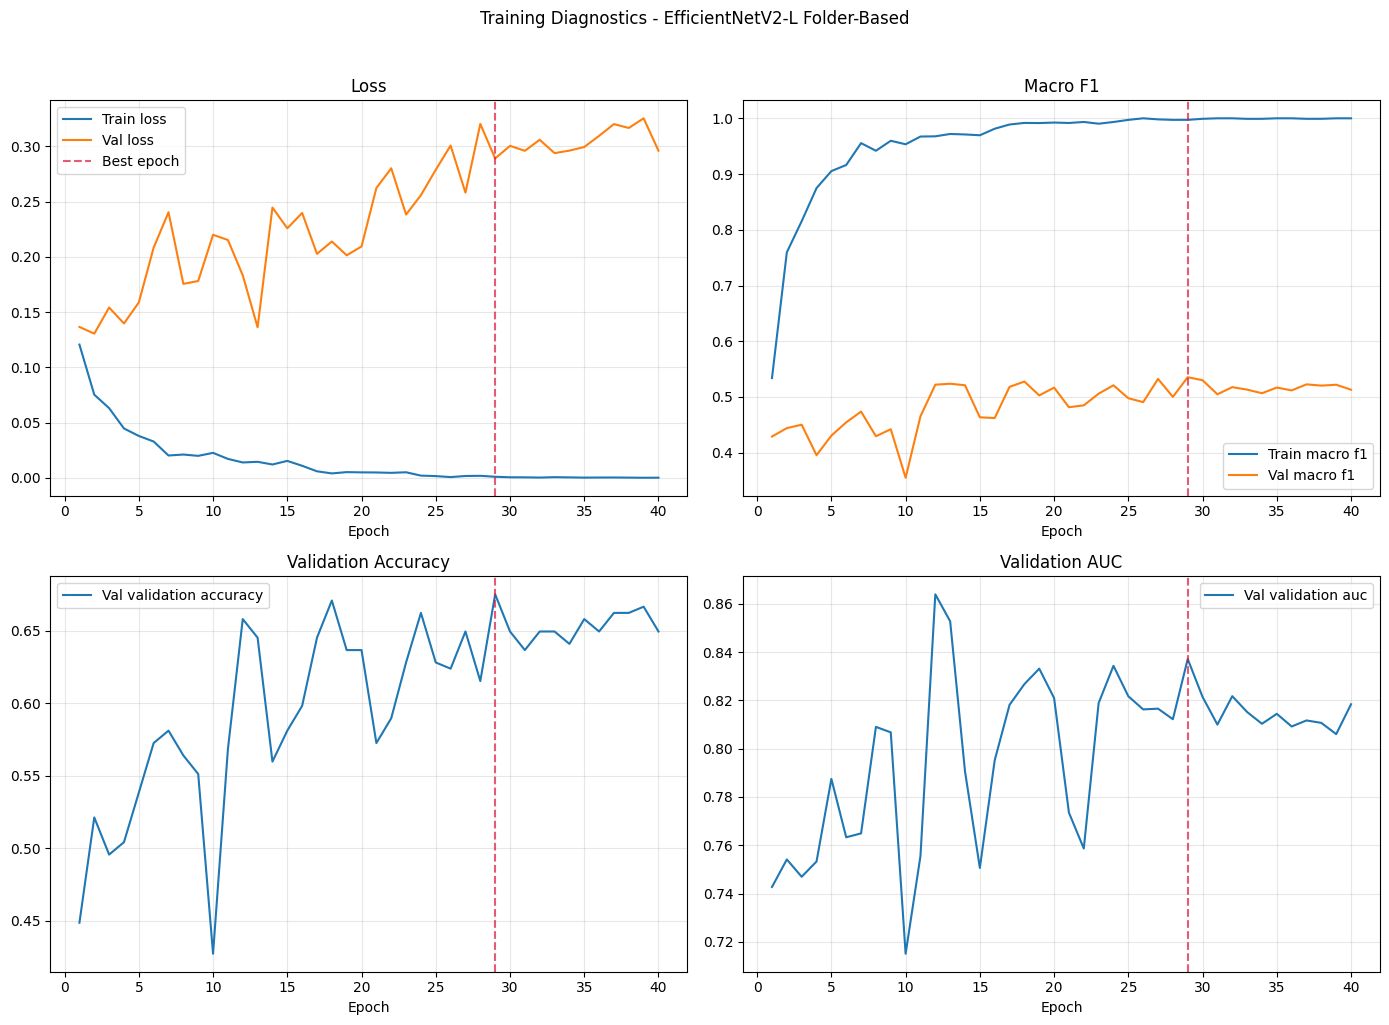

In [8]:
# Validation history and diagnostics
history_df = history_df.sort_values('epoch').reset_index(drop=True)
print('Best epoch:', best_epoch)
print('Best val macro F1:', best_val_f1)

display(history_df.tail())

plot_cols = [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_macro_f1', 'val_macro_f1', 'Macro F1'),
    (None, 'val_accuracy', 'Validation Accuracy'),
    (None, 'val_auc', 'Validation AUC'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, (train_col, val_col, title) in zip(axes, plot_cols):
    if train_col is not None and train_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[train_col], label=f'Train {title.lower()}')
    if val_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[val_col], label=f'Val {title.lower()}')
    ax.axvline(best_epoch, color='crimson', linestyle='--', alpha=0.7, label='Best epoch' if ax is axes[0] else None)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Training Diagnostics - EfficientNetV2-L Folder-Based', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_efficientnet_v2l_folder_based.png'), dpi=200, bbox_inches='tight')
plt.show()